# Final Project: Global City Environmental Health Risk Analysis

**Class:** Data Analysis with Python and SQL  
**Authors:** Amy Tao and Victor Doddy  

## Target audience

The target audience is an analyst advising relocation teams, employers, or internationally mobile households that want a practical, health-oriented comparison of selected global cities. The analysis is not meant to declare one city universally “best.” Instead, it identifies which cities in this small sample appear to combine worse current air quality with higher long-run heat exposure.

## Business question

**Which selected global cities look more concerning from an environmental health perspective when current air quality is combined with long-run heat patterns?**

## Why this matters

A relocation decision often focuses on cost, job opportunities, schools, and culture. Environmental health risk is harder to summarize because it combines short-term conditions, such as current air quality, with long-term patterns, such as heat exposure. We use Python and SQLite to combine multiple datasets, check data quality, engineer interpretable risk features, run EDA, and build two models that support a final recommendation.

## Datasets

1. **IQAir AirVisual API:** current city-level air quality.
2. **Open-Meteo Historical Weather API:** daily weather history from 2000 through 2025.
3. **City context table:** manually curated city metadata used for segmentation, joining, and feature engineering.

In [37]:
import os
import sqlite3
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

CURRENT_AQ_PATH = DATA_DIR / 'current_aq.csv'
WEATHER_PATH = DATA_DIR / 'daily_weather.csv'
SQLITE_PATH = DATA_DIR / 'global_city_environment.sqlite'
SQL_SCRIPT_PATH = Path('Final_Project_SQL_Queries.sql')

## 1. City selection and city context dataset

The sample keeps the project focused and explainable while still allowing cross-city comparisons. The city context table is a small second/third dataset used to segment results by region, coastal status, and broad climate type. It also creates useful categorical features for modeling.

In [2]:
cities = [
    {'city': 'New York', 'state': 'New York', 'country': 'USA', 'latitude': 40.7128, 'longitude': -74.0060},
    {'city': 'Los Angeles', 'state': 'California', 'country': 'USA', 'latitude': 34.0522, 'longitude': -118.2437},
    {'city': 'London', 'state': 'England', 'country': 'United Kingdom', 'latitude': 51.5072, 'longitude': -0.1276},
    {'city': 'Paris', 'state': 'Ile-de-France', 'country': 'France', 'latitude': 48.8566, 'longitude': 2.3522},
    {'city': 'Tokyo', 'state': 'Tokyo', 'country': 'Japan', 'latitude': 35.6762, 'longitude': 139.6503},
    {'city': 'New Delhi', 'state': 'Delhi', 'country': 'India', 'latitude': 28.6139, 'longitude': 77.2090},
]

cities_df = pd.DataFrame(cities)

city_context = [
    {'city': 'New York', 'country': 'USA', 'region': 'North America', 'coastal_city': 1, 'climate_group': 'temperate', 'approx_population_millions': 8.3},
    {'city': 'Los Angeles', 'country': 'USA', 'region': 'North America', 'coastal_city': 1, 'climate_group': 'mediterranean', 'approx_population_millions': 3.8},
    {'city': 'London', 'country': 'United Kingdom', 'region': 'Europe', 'coastal_city': 0, 'climate_group': 'temperate', 'approx_population_millions': 8.9},
    {'city': 'Paris', 'country': 'France', 'region': 'Europe', 'coastal_city': 0, 'climate_group': 'temperate', 'approx_population_millions': 2.1},
    {'city': 'Tokyo', 'country': 'Japan', 'region': 'Asia', 'coastal_city': 1, 'climate_group': 'humid_subtropical', 'approx_population_millions': 14.0},
    {'city': 'New Delhi', 'country': 'India', 'region': 'Asia', 'coastal_city': 0, 'climate_group': 'semi_arid', 'approx_population_millions': 11.0},
]

city_context_df = pd.DataFrame(city_context)
city_context_df

,city,country,region,coastal_city,climate_group,approx_population_millions
0,New York,USA,North America,1,temperate,8.300
1,Los Angeles,USA,North America,1,mediterranean,3.800
2,London,United Kingdom,Europe,0,temperate,8.900
3,Paris,France,Europe,0,temperate,2.100
4,Tokyo,Japan,Asia,1,humid_subtropical,14.000
5,New Delhi,India,Asia,0,semi_arid,11.000


## 2. Data acquisition

If the CSVs already exist, we read them. If not, we call the APIs and save the results. This makes the notebook easier to rerun and avoids unnecessary API calls.

In [3]:
def classify_aqi(aqi):
    if pd.isna(aqi):
        return np.nan
    if aqi <= 50:
        return 'Good'
    if aqi <= 100:
        return 'Moderate'
    if aqi <= 150:
        return 'Unhealthy for Sensitive Groups'
    if aqi <= 200:
        return 'Unhealthy'
    if aqi <= 300:
        return 'Very Unhealthy'
    return 'Hazardous'


def get_current_aq(cities_df, force_refresh=False):
    if CURRENT_AQ_PATH.exists() and not force_refresh:
        df = pd.read_csv(CURRENT_AQ_PATH, parse_dates=['current_timestamp'])
        return df

    api_key = "d9c31575-511f-4442-8f77-0d73dc4e780d"

    rows = []
    failed = []
    url = 'https://api.airvisual.com/v2/city'

    for _, item in cities_df.iterrows():
        params = {
            'city': item['city'],
            'state': item['state'],
            'country': item['country'],
            'key': api_key,
        }
        try:
            response = requests.get(url, params=params, timeout=30)
            data = response.json()
            if response.status_code == 200 and data.get('status') == 'success':
                current = data['data']['current']
                pollution = current['pollution']
                weather = current['weather']
                location = data['data']['location']['coordinates']
                rows.append({
                    'city': item['city'],
                    'country': item['country'],
                    'latitude': location[1],
                    'longitude': location[0],
                    'current_aqius': pollution.get('aqius'),
                    'main_pollutant_us': pollution.get('mainus'),
                    'current_temperature_c': weather.get('tp'),
                    'current_humidity': weather.get('hu'),
                    'current_wind_speed': weather.get('ws'),
                    'current_timestamp': pollution.get('ts'),
                })
            else:
                failed.append({'city': item['city'], 'status_code': response.status_code, 'api_status': data.get('status'), 'message': data.get('data')})
        except Exception as e:
            failed.append({'city': item['city'], 'status_code': None, 'api_status': 'request_failed', 'message': str(e)})

        time.sleep(15)

    if failed:
        display(pd.DataFrame(failed))

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError('No current AQI rows returned. Check the API key, city names, and API limits.')

    df['current_timestamp'] = pd.to_datetime(df['current_timestamp'], errors='coerce')
    df['current_aqi_category'] = df['current_aqius'].apply(classify_aqi)
    df['high_current_aqi'] = (df['current_aqius'] > 100).astype(int)
    df.to_csv(CURRENT_AQ_PATH, index=False)
    return df


def get_daily_weather(cities_df, start_date='2000-01-01', end_date='2025-12-31', force_refresh=False):
    if WEATHER_PATH.exists() and not force_refresh:
        return pd.read_csv(WEATHER_PATH, parse_dates=['date'])

    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude': ','.join(cities_df['latitude'].astype(str)),
        'longitude': ','.join(cities_df['longitude'].astype(str)),
        'start_date': start_date,
        'end_date': end_date,
        'daily': 'temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,wind_speed_10m_max',
        'timezone': 'auto',
    }

    response = requests.get(url, params=params, timeout=60)
    if response.status_code != 200:
        raise ValueError(f'Open-Meteo request failed with status code {response.status_code}: {response.text[:500]}')

    weather_json = response.json()
    if isinstance(weather_json, dict):
        weather_json = [weather_json]

    rows = []
    for i, city_weather in enumerate(weather_json):
        daily = pd.DataFrame(city_weather['daily'])
        daily['city'] = cities_df.iloc[i]['city']
        daily['country'] = cities_df.iloc[i]['country']
        rows.append(daily)

    df = pd.concat(rows, ignore_index=True)
    df['date'] = pd.to_datetime(df['time'], errors='coerce')
    df = df.drop(columns=['time'])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df.to_csv(WEATHER_PATH, index=False)
    return df

In [4]:
current_aq_df = get_current_aq(cities_df)
weather_df = get_daily_weather(cities_df)

print(current_aq_df.shape)
print(weather_df.shape)
display(current_aq_df.head())
display(weather_df.head())

(6, 12)
(56982, 10)


,city,country,latitude,longitude,current_aqius,main_pollutant_us,current_temperature_c,current_humidity,current_wind_speed,current_timestamp,current_aqi_category,high_current_aqi
0,New York,USA,40.663,-73.939,33,p2,22,72,3.610,2026-05-25 19:00:00+00:00,Good,0
1,Los Angeles,USA,34.019,-118.411,39,p2,19,66,3.330,2026-05-25 19:00:00+00:00,Good,0
2,London,United Kingdom,51.456,0.041,54,p2,27,38,2.220,2026-05-25 19:00:00+00:00,Moderate,0
3,Paris,France,48.859,2.352,67,p2,30,43,1.940,2026-05-25 19:00:00+00:00,Moderate,0
4,Tokyo,Japan,35.690,139.692,22,p2,19,88,1.670,2026-05-25 18:00:00+00:00,Good,0


,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,city,country,date,year,month
0,9.600,-2.900,2.100,0.000,12.200,New York,USA,2000-01-01,2000,1
1,14.500,0.700,7.200,0.000,18.100,New York,USA,2000-01-02,2000,1
2,15.700,10.300,11.600,1.100,17.100,New York,USA,2000-01-03,2000,1
3,15.800,9.100,13.000,16.200,24.300,New York,USA,2000-01-04,2000,1
4,8.200,-2.800,2.500,3.200,25.000,New York,USA,2000-01-05,2000,1


## 3. Data quality checks

These checks cover missing values, duplicates, categorical values, date coverage, and basic validity conditions. This is important because the analysis combines two APIs with different grain: one row per city for current AQI and one row per city-date for weather.

In [5]:
# Table 1: missingness summary for current AQI
current_missing = (
    current_aq_df.isna().sum()
    .reset_index()
    .rename(columns={'index': 'column', 0: 'missing_count'})
)
current_missing['missing_share'] = current_missing['missing_count'] / len(current_aq_df)
current_missing

,column,missing_count,missing_share
0,city,0,0.000
1,country,0,0.000
2,latitude,0,0.000
3,longitude,0,0.000
4,current_aqius,0,0.000
5,main_pollutant_us,0,0.000
6,current_temperature_c,0,0.000
7,current_humidity,0,0.000
8,current_wind_speed,0,0.000
9,current_timestamp,0,0.000


In [6]:
# Table 2: missingness summary for historical weather
weather_missing = (
    weather_df.isna().sum()
    .reset_index()
    .rename(columns={'index': 'column', 0: 'missing_count'})
)
weather_missing['missing_share'] = weather_missing['missing_count'] / len(weather_df)
weather_missing

,column,missing_count,missing_share
0,temperature_2m_max,0,0.000
1,temperature_2m_min,0,0.000
2,temperature_2m_mean,0,0.000
3,precipitation_sum,0,0.000
4,wind_speed_10m_max,0,0.000
5,city,0,0.000
6,country,0,0.000
7,date,0,0.000
8,year,0,0.000
9,month,0,0.000


In [7]:
quality_checks = {
    'current_duplicate_city_rows': int(current_aq_df.duplicated(['city', 'country']).sum()),
    'weather_duplicate_city_date_rows': int(weather_df.duplicated(['city', 'country', 'date']).sum()),
    'weather_min_temp_above_max_temp_rows': int((weather_df['temperature_2m_min'] > weather_df['temperature_2m_max']).sum()),
    'negative_precipitation_rows': int((weather_df['precipitation_sum'] < 0).sum()),
    'negative_wind_speed_rows': int((weather_df['wind_speed_10m_max'] < 0).sum()),
}

quality_summary = pd.DataFrame(list(quality_checks.items()), columns=['check', 'problem_rows'])
quality_summary

,check,problem_rows
0,current_duplicate_city_rows,0
1,weather_duplicate_city_date_rows,0
2,weather_min_temp_above_max_temp_rows,0
3,negative_precipitation_rows,0
4,negative_wind_speed_rows,0


In [8]:
# Table 3: expected row counts and date coverage by city
coverage_by_city = (
    weather_df.groupby(['city', 'country'], as_index=False)
    .agg(
        first_date=('date', 'min'),
        last_date=('date', 'max'),
        row_count=('date', 'count'),
        unique_years=('year', 'nunique'),
    )
)
coverage_by_city

,city,country,first_date,last_date,row_count,unique_years
0,London,United Kingdom,2000-01-01,2025-12-31,9497,26
1,Los Angeles,USA,2000-01-01,2025-12-31,9497,26
2,New Delhi,India,2000-01-01,2025-12-31,9497,26
3,New York,USA,2000-01-01,2025-12-31,9497,26
4,Paris,France,2000-01-01,2025-12-31,9497,26
5,Tokyo,Japan,2000-01-01,2025-12-31,9497,26


In [9]:
print('Current AQI categories:')
print(current_aq_df['current_aqi_category'].value_counts(dropna=False))

print('Main pollutant values:')
print(current_aq_df['main_pollutant_us'].value_counts(dropna=False))

weather_df[['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max']].describe()

Current AQI categories:
current_aqi_category
Good              3
Moderate          2
Very Unhealthy    1
Name: count, dtype: int64
Main pollutant values:
main_pollutant_us
p2    5
p1    1
Name: count, dtype: int64


,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,wind_speed_10m_max
count,"56,982.000","56,982.000","56,982.000","56,982.000","56,982.000"
mean,20.304,11.114,15.476,2.336,17.967
std,9.470,8.251,8.617,6.630,7.523
min,-12.700,-20.700,-15.000,0.000,3.400
25%,13.000,5.300,9.300,0.000,12.600
50%,20.400,10.900,15.500,0.000,16.400
75%,27.400,16.700,21.700,1.400,21.600
max,46.000,34.500,39.500,187.200,95.900


## 4. Feature engineering

The engineered features below connect the raw data to the target audience’s decision. Heat flags are easier to interpret than raw Celsius values alone. Seasonal and lag/trend features support EDA and modeling. The combined risk score is deliberately simple and explainable, not a medical or epidemiological claim.

In [10]:
weather_df = weather_df.copy()
weather_df['temperature_range_c'] = weather_df['temperature_2m_max'] - weather_df['temperature_2m_min']
weather_df['hot_day'] = (weather_df['temperature_2m_max'] >= 32).astype(int)
weather_df['very_hot_day'] = (weather_df['temperature_2m_max'] >= 35).astype(int)
weather_df['rainy_day'] = (weather_df['precipitation_sum'] > 0).astype(int)
weather_df['high_wind_day'] = (weather_df['wind_speed_10m_max'] >= weather_df['wind_speed_10m_max'].quantile(0.90)).astype(int)
weather_df['season'] = weather_df['month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring', 6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Fall', 10: 'Fall', 11: 'Fall'})

current_aq_df = current_aq_df.copy()
current_aq_df['current_aqi_category'] = current_aq_df['current_aqius'].apply(classify_aqi)
current_aq_df['high_current_aqi'] = (current_aq_df['current_aqius'] > 100).astype(int)
current_aq_df['pollutant_group'] = current_aq_df['main_pollutant_us'].map({'p2': 'Fine particulate matter', 'p1': 'Coarse particulate matter'}).fillna('Other / unknown')

# apply/map requirement: classify days based on max temperature
def temp_risk_label(max_temp):
    if max_temp >= 35:
        return 'very hot'
    if max_temp >= 32:
        return 'hot'
    if max_temp <= 0:
        return 'freezing'
    return 'normal'

weather_df['temperature_risk_label'] = weather_df['temperature_2m_max'].apply(temp_risk_label)

display(weather_df.head())
display(current_aq_df[['city', 'current_aqius', 'current_aqi_category', 'high_current_aqi', 'pollutant_group']].sort_values('current_aqius', ascending=False))

,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,city,country,date,year,month,temperature_range_c,hot_day,very_hot_day,rainy_day,high_wind_day,season,temperature_risk_label
0,9.600,-2.900,2.100,0.000,12.200,New York,USA,2000-01-01,2000,1,12.500,0,0,0,0,Winter,normal
1,14.500,0.700,7.200,0.000,18.100,New York,USA,2000-01-02,2000,1,13.800,0,0,0,0,Winter,normal
2,15.700,10.300,11.600,1.100,17.100,New York,USA,2000-01-03,2000,1,5.400,0,0,1,0,Winter,normal
3,15.800,9.100,13.000,16.200,24.300,New York,USA,2000-01-04,2000,1,6.700,0,0,1,0,Winter,normal
4,8.200,-2.800,2.500,3.200,25.000,New York,USA,2000-01-05,2000,1,11.000,0,0,1,0,Winter,normal


,city,current_aqius,current_aqi_category,high_current_aqi,pollutant_group
5,New Delhi,233,Very Unhealthy,1,Coarse particulate matter
3,Paris,67,Moderate,0,Fine particulate matter
2,London,54,Moderate,0,Fine particulate matter
1,Los Angeles,39,Good,0,Fine particulate matter
0,New York,33,Good,0,Fine particulate matter
4,Tokyo,22,Good,0,Fine particulate matter


## 5. Python EDA

This section includes the required aggregate tables, Pandas groupbys, and non-Pandas charts. Charts are created directly with Matplotlib rather than Pandas built-in plotting.

In [11]:
# Pandas groupby 1: long-run weather by city
city_weather_summary = (
    weather_df
    .groupby(['city', 'country'], as_index=False)
    .agg(
        avg_max_temp_c=('temperature_2m_max', 'mean'),
        avg_mean_temp_c=('temperature_2m_mean', 'mean'),
        hottest_day_c=('temperature_2m_max', 'max'),
        hot_day_share=('hot_day', 'mean'),
        very_hot_day_share=('very_hot_day', 'mean'),
        rainy_day_share=('rainy_day', 'mean'),
        avg_wind_speed=('wind_speed_10m_max', 'mean'),
    )
)
city_weather_summary.sort_values('hot_day_share', ascending=False)

,city,country,avg_max_temp_c,avg_mean_temp_c,hottest_day_c,hot_day_share,very_hot_day_share,rainy_day_share,avg_wind_speed
2,New Delhi,India,30.611,24.688,46.000,0.471,0.258,0.348,14.495
1,Los Angeles,USA,24.964,17.951,45.700,0.150,0.050,0.159,14.012
5,Tokyo,Japan,19.275,15.194,39.300,0.049,0.010,0.519,21.964
3,New York,USA,16.513,12.049,40.400,0.035,0.006,0.473,18.431
4,Paris,France,15.932,11.960,40.700,0.011,0.004,0.554,18.264
0,London,United Kingdom,14.529,11.017,37.900,0.002,0.000,0.560,20.635


In [12]:
# Pandas groupby 2: annual trends by city
annual_weather = (
    weather_df
    .groupby(['city', 'country', 'year'], as_index=False)
    .agg(
        avg_max_temp_c=('temperature_2m_max', 'mean'),
        hot_days=('hot_day', 'sum'),
        very_hot_days=('very_hot_day', 'sum'),
        rainy_days=('rainy_day', 'sum'),
        avg_precipitation=('precipitation_sum', 'mean'),
        avg_temp_range_c=('temperature_range_c', 'mean'),
    )
)
annual_weather.head(12)

,city,country,year,avg_max_temp_c,hot_days,very_hot_days,rainy_days,avg_precipitation,avg_temp_range_c
0,London,United Kingdom,2000,13.935,0,0,225,2.350,6.616
1,London,United Kingdom,2001,13.694,0,0,197,2.039,6.897
2,London,United Kingdom,2002,14.362,0,0,211,1.973,6.579
3,London,United Kingdom,2003,14.708,2,0,160,1.515,7.488
4,London,United Kingdom,2004,14.161,0,0,197,1.661,6.753
5,London,United Kingdom,2005,14.356,0,0,182,1.397,6.987
6,London,United Kingdom,2006,14.679,0,0,191,1.716,6.732
7,London,United Kingdom,2007,14.399,0,0,188,1.772,6.912
8,London,United Kingdom,2008,13.790,0,0,210,1.843,6.812
9,London,United Kingdom,2009,13.918,0,0,181,1.697,6.860


In [13]:
# Pandas groupby 3: seasonal heat patterns
seasonal_weather = (
    weather_df
    .groupby(['city', 'country', 'season'], as_index=False)
    .agg(
        avg_max_temp_c=('temperature_2m_max', 'mean'),
        hot_day_share=('hot_day', 'mean'),
        rainy_day_share=('rainy_day', 'mean'),
        observations=('date', 'count'),
    )
)
seasonal_weather.sort_values(['city', 'hot_day_share'], ascending=[True, False])

,city,country,season,avg_max_temp_c,hot_day_share,rainy_day_share,observations
2,London,United Kingdom,Summer,21.282,0.007,0.592,2392
0,London,United Kingdom,Fall,14.982,0.000,0.557,2366
1,London,United Kingdom,Spring,13.815,0.000,0.540,2392
3,London,United Kingdom,Winter,7.919,0.000,0.549,2347
6,Los Angeles,USA,Summer,30.424,0.340,0.051,2392
4,Los Angeles,USA,Fall,27.032,0.208,0.138,2366
5,Los Angeles,USA,Spring,23.140,0.048,0.202,2392
7,Los Angeles,USA,Winter,19.173,0.001,0.247,2347
10,New Delhi,India,Summer,34.764,0.764,0.739,2392
9,New Delhi,India,Spring,35.198,0.729,0.253,2392


In [14]:
early_period = annual_weather[annual_weather['year'].between(2000, 2004)]
recent_period = annual_weather[annual_weather['year'].between(2021, 2025)]

early_summary = early_period.groupby(['city', 'country'], as_index=False).agg(
    early_avg_hot_days=('hot_days', 'mean'),
    early_avg_max_temp_c=('avg_max_temp_c', 'mean'),
)

recent_summary = recent_period.groupby(['city', 'country'], as_index=False).agg(
    recent_avg_hot_days=('hot_days', 'mean'),
    recent_avg_max_temp_c=('avg_max_temp_c', 'mean'),
)

weather_change = pd.merge(early_summary, recent_summary, on=['city', 'country'])
weather_change['change_in_avg_hot_days'] = weather_change['recent_avg_hot_days'] - weather_change['early_avg_hot_days']
weather_change['change_in_avg_max_temp_c'] = weather_change['recent_avg_max_temp_c'] - weather_change['early_avg_max_temp_c']
weather_change.sort_values('change_in_avg_hot_days', ascending=False)

,city,country,early_avg_hot_days,early_avg_max_temp_c,recent_avg_hot_days,recent_avg_max_temp_c,change_in_avg_hot_days,change_in_avg_max_temp_c
5,Tokyo,Japan,9.200,18.623,42.400,20.830,33.200,2.207
3,New York,USA,8.600,15.740,19.600,17.470,11.000,1.730
1,Los Angeles,USA,47.200,24.271,52.400,24.807,5.200,0.536
4,Paris,France,3.600,15.555,5.000,16.610,1.400,1.055
0,London,United Kingdom,0.400,14.172,1.200,15.446,0.800,1.274
2,New Delhi,India,174.000,30.758,171.000,30.482,-3.000,-0.276


In [15]:
combined_summary = (
    current_aq_df[['city', 'country', 'current_aqius', 'main_pollutant_us', 'current_aqi_category', 'high_current_aqi']]
    .merge(city_weather_summary, on=['city', 'country'], how='inner')
    .merge(weather_change[['city', 'country', 'change_in_avg_hot_days', 'change_in_avg_max_temp_c']], on=['city', 'country'], how='inner')
    .merge(city_context_df, on=['city', 'country'], how='inner')
)

combined_summary['aqi_percent_rank'] = combined_summary['current_aqius'].rank(pct=True)
combined_summary['heat_percent_rank'] = combined_summary['hot_day_share'].rank(pct=True)
combined_summary['trend_percent_rank'] = combined_summary['change_in_avg_hot_days'].rank(pct=True)
combined_summary['simple_environmental_risk_score'] = (
    0.40 * combined_summary['aqi_percent_rank'] +
    0.40 * combined_summary['heat_percent_rank'] +
    0.20 * combined_summary['trend_percent_rank']
)

combined_summary.sort_values('simple_environmental_risk_score', ascending=False)

,city,country,current_aqius,main_pollutant_us,current_aqi_category,high_current_aqi,avg_max_temp_c,avg_mean_temp_c,hottest_day_c,hot_day_share,very_hot_day_share,rainy_day_share,avg_wind_speed,change_in_avg_hot_days,change_in_avg_max_temp_c,region,coastal_city,climate_group,approx_population_millions,aqi_percent_rank,heat_percent_rank,trend_percent_rank,simple_environmental_risk_score
5,New Delhi,India,233,p1,Very Unhealthy,1,30.611,24.688,46.000,0.471,0.258,0.348,14.495,-3.000,-0.276,Asia,0,semi_arid,11.000,1.000,1.000,0.167,0.833
1,Los Angeles,USA,39,p2,Good,0,24.964,17.951,45.700,0.150,0.050,0.159,14.012,5.200,0.536,North America,1,mediterranean,3.800,0.500,0.833,0.667,0.667
3,Paris,France,67,p2,Moderate,0,15.932,11.960,40.700,0.011,0.004,0.554,18.264,1.400,1.055,Europe,0,temperate,2.100,0.833,0.333,0.500,0.567
4,Tokyo,Japan,22,p2,Good,0,19.275,15.194,39.300,0.049,0.010,0.519,21.964,33.200,2.207,Asia,1,humid_subtropical,14.000,0.167,0.667,1.000,0.533
0,New York,USA,33,p2,Good,0,16.513,12.049,40.400,0.035,0.006,0.473,18.431,11.000,1.730,North America,1,temperate,8.300,0.333,0.500,0.833,0.500
2,London,United Kingdom,54,p2,Moderate,0,14.529,11.017,37.900,0.002,0.000,0.560,20.635,0.800,1.274,Europe,0,temperate,8.900,0.667,0.167,0.333,0.400


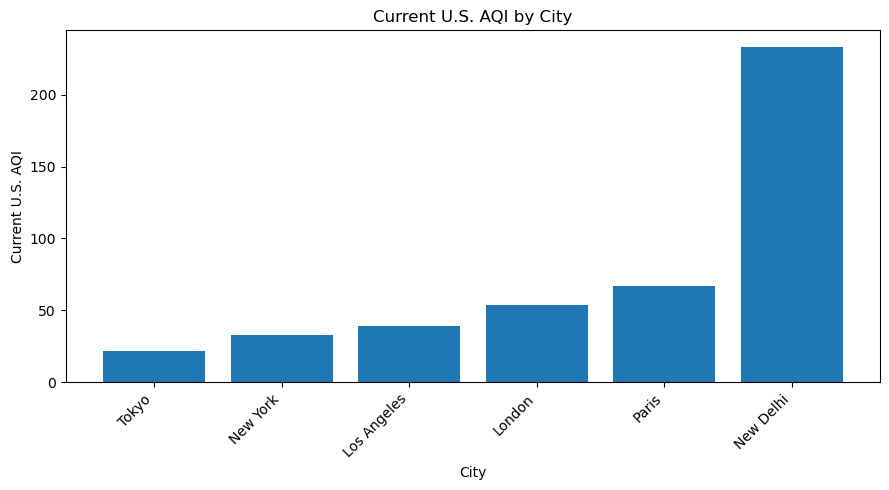

In [16]:
# Chart 1: current AQI by city
plot_df = current_aq_df.sort_values('current_aqius')
plt.figure(figsize=(9, 5))
plt.bar(plot_df['city'], plot_df['current_aqius'])
plt.title('Current U.S. AQI by City')
plt.xlabel('City')
plt.ylabel('Current U.S. AQI')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

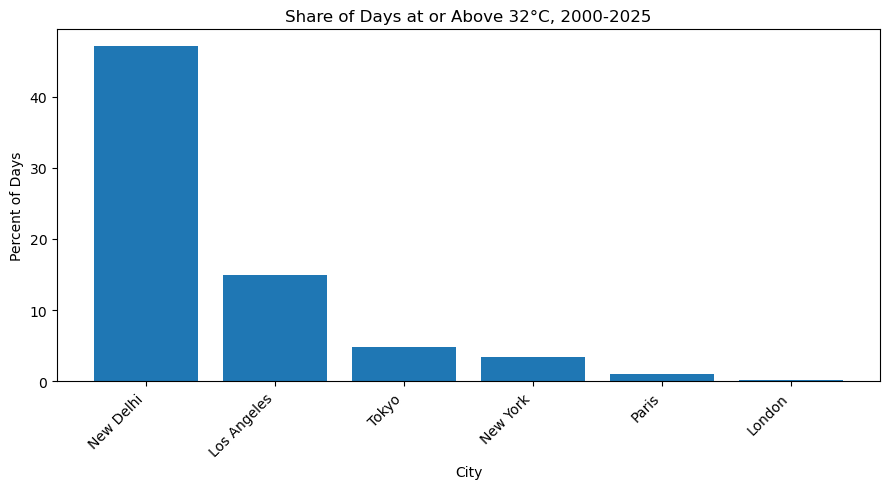

In [17]:
# Chart 2: long-run share of hot days
plot_df = city_weather_summary.sort_values('hot_day_share', ascending=False)
plt.figure(figsize=(9, 5))
plt.bar(plot_df['city'], plot_df['hot_day_share'] * 100)
plt.title('Share of Days at or Above 32°C, 2000-2025')
plt.xlabel('City')
plt.ylabel('Percent of Days')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

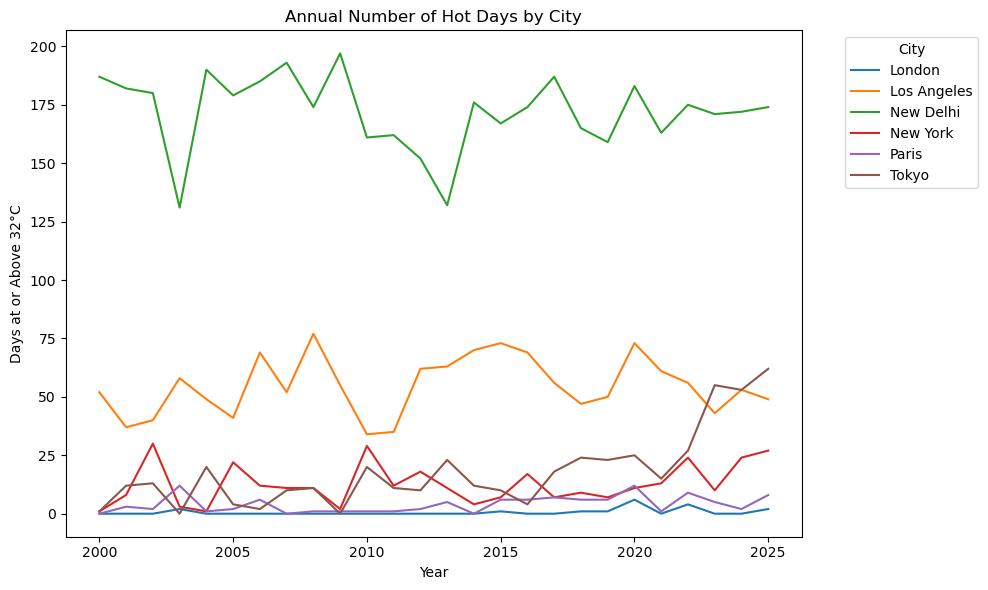

In [18]:
# Chart 3: annual hot days by city
plt.figure(figsize=(10, 6))
for city in annual_weather['city'].unique():
    city_data = annual_weather[annual_weather['city'] == city]
    plt.plot(city_data['year'], city_data['hot_days'], label=city)
plt.title('Annual Number of Hot Days by City')
plt.xlabel('Year')
plt.ylabel('Days at or Above 32°C')
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

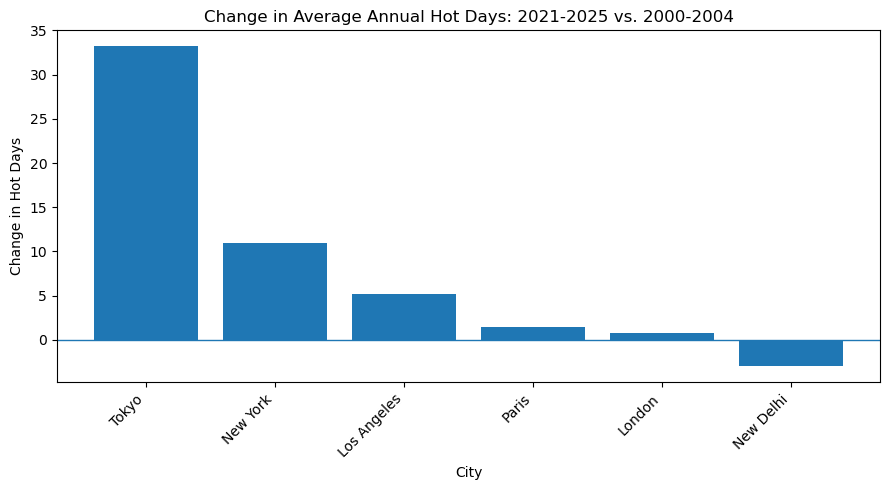

In [19]:
# Chart 4: change in average annual hot days
plot_df = weather_change.sort_values('change_in_avg_hot_days', ascending=False)
plt.figure(figsize=(9, 5))
plt.bar(plot_df['city'], plot_df['change_in_avg_hot_days'])
plt.title('Change in Average Annual Hot Days: 2021-2025 vs. 2000-2004')
plt.xlabel('City')
plt.ylabel('Change in Hot Days')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

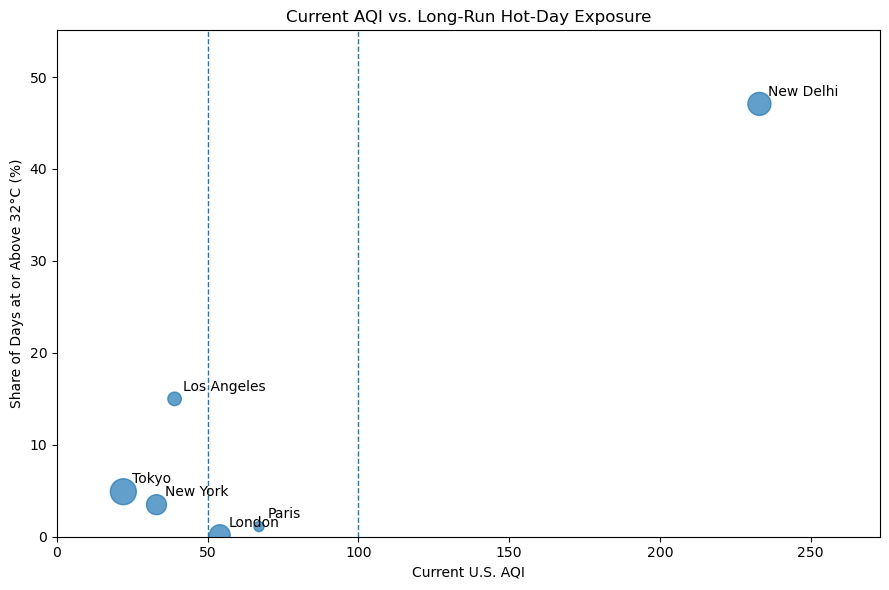

In [20]:
# Chart 5: combined current AQI and long-run heat exposure
plot_df = combined_summary.copy()

plt.figure(figsize=(9, 6))
plt.scatter(
    plot_df['current_aqius'],
    plot_df['hot_day_share'] * 100,
    s=plot_df['approx_population_millions'] * 25,
    alpha=0.7
)

for _, row in plot_df.iterrows():
    plt.annotate(
        row['city'],
        (row['current_aqius'], row['hot_day_share'] * 100),
        xytext=(6, 6),
        textcoords='offset points'
    )

plt.axvline(50, linestyle='--', linewidth=1)
plt.axvline(100, linestyle='--', linewidth=1)

plt.title('Current AQI vs. Long-Run Hot-Day Exposure')
plt.xlabel('Current U.S. AQI')
plt.ylabel('Share of Days at or Above 32°C (%)')
plt.xlim(0, plot_df['current_aqius'].max() + 40)
plt.ylim(0, plot_df['hot_day_share'].max() * 100 + 8)
plt.tight_layout()
plt.show()

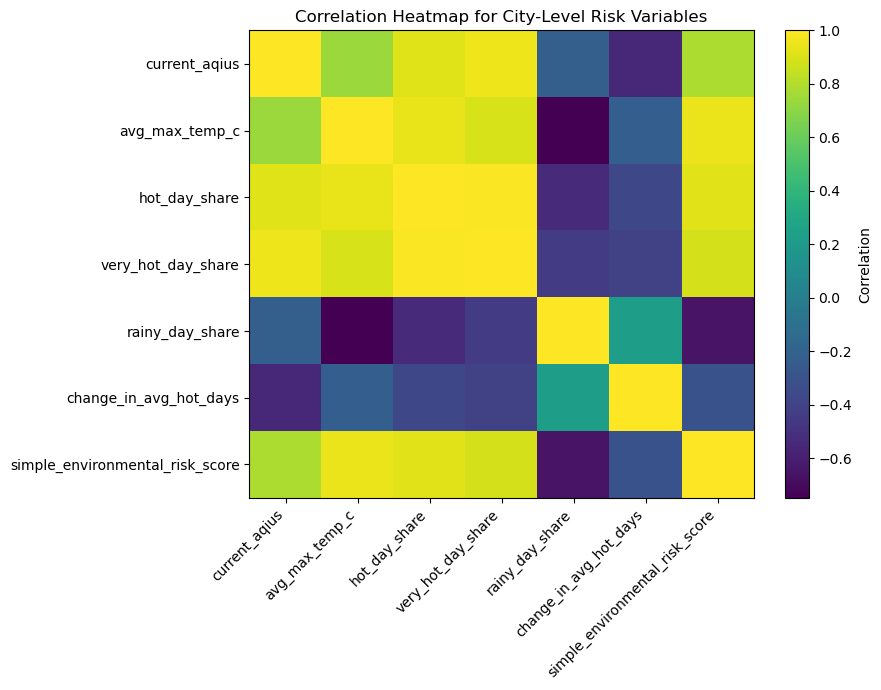

,current_aqius,avg_max_temp_c,hot_day_share,very_hot_day_share,rainy_day_share,change_in_avg_hot_days,simple_environmental_risk_score
current_aqius,1.000,0.739,0.913,0.954,-0.219,-0.555,0.784
avg_max_temp_c,0.739,1.000,0.942,0.897,-0.749,-0.226,0.950
hot_day_share,0.913,0.942,1.000,0.993,-0.540,-0.372,0.920
very_hot_day_share,0.954,0.897,0.993,1.000,-0.442,-0.414,0.888
rainy_day_share,-0.219,-0.749,-0.540,-0.442,1.000,0.222,-0.657
change_in_avg_hot_days,-0.555,-0.226,-0.372,-0.414,0.222,1.000,-0.310
simple_environmental_risk_score,0.784,0.950,0.920,0.888,-0.657,-0.310,1.000


In [21]:
# Chart 6: correlation heatmap for key numeric variables
numeric_cols = ['current_aqius', 'avg_max_temp_c', 'hot_day_share', 'very_hot_day_share', 'rainy_day_share', 'change_in_avg_hot_days', 'simple_environmental_risk_score']
corr = combined_summary[numeric_cols].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title('Correlation Heatmap for City-Level Risk Variables')
plt.tight_layout()
plt.show()

corr

## 6. SQLite database and SQL analysis

We create a SQLite database from the cleaned Python data. The file `Final_Project_SQL_Queries.sql` contains 12 queries w/ comments for every query.

In [22]:
# Prepare SQLite-friendly tables
sql_weather = weather_df.copy()
sql_weather['date'] = sql_weather['date'].dt.strftime('%Y-%m-%d')

sql_current = current_aq_df.copy()
sql_current['current_timestamp'] = pd.to_datetime(sql_current['current_timestamp'], errors='coerce').dt.strftime('%Y-%m-%d %H:%M:%S')

with sqlite3.connect(SQLITE_PATH) as conn:
    sql_current.to_sql('current_aq', conn, if_exists='replace', index=False)
    sql_weather.to_sql('daily_weather', conn, if_exists='replace', index=False)
    city_context_df.to_sql('city_context', conn, if_exists='replace', index=False)

print(f'Created SQLite database at: {SQLITE_PATH}')

Created SQLite database at: data/global_city_environment.sqlite


In [23]:
def run_sql(query):
    with sqlite3.connect(SQLITE_PATH) as conn:
        return pd.read_sql_query(query, conn)

# Example: the combined SQL-style output used in the narrative
combined_sql = run_sql('''
SELECT
    aq.city,
    aq.country,
    aq.current_aqius,
    aq.current_aqi_category,
    w.avg_max_temp_c,
    w.hot_day_share,
    c.region,
    c.climate_group
FROM current_aq AS aq
JOIN (
    SELECT
        city,
        country,
        AVG(temperature_2m_max) AS avg_max_temp_c,
        AVG(CASE WHEN hot_day = 1 THEN 1.0 ELSE 0.0 END) AS hot_day_share
    FROM daily_weather
    GROUP BY city, country
) AS w
    ON aq.city = w.city AND aq.country = w.country
JOIN city_context AS c
    ON aq.city = c.city AND aq.country = c.country
ORDER BY aq.current_aqius DESC;
''')
combined_sql

,city,country,current_aqius,current_aqi_category,avg_max_temp_c,hot_day_share,region,climate_group
0,New Delhi,India,233,Very Unhealthy,30.611,0.471,Asia,semi_arid
1,Paris,France,67,Moderate,15.932,0.011,Europe,temperate
2,London,United Kingdom,54,Moderate,14.529,0.002,Europe,temperate
3,Los Angeles,USA,39,Good,24.964,0.150,North America,mediterranean
4,New York,USA,33,Good,16.513,0.035,North America,temperate
5,Tokyo,Japan,22,Good,19.275,0.049,Asia,humid_subtropical


In [24]:
# We run each query from the required SQL file and preview output shapes.
import re

if SQL_SCRIPT_PATH.exists():
    sql_text = SQL_SCRIPT_PATH.read_text()
    query_blocks = re.split(r'(?=-- Q\d+:)', sql_text)
    query_blocks = [q.strip() for q in query_blocks if q.strip().startswith('-- Q')]
    print(f'Found {len(query_blocks)} required SQL queries.')
    for i, block in enumerate(query_blocks, start=1):
        query = '\n'.join(line for line in block.splitlines() if not line.strip().startswith('--')).strip()
        if query:
            result = run_sql(query)
            print(f'Q{i}: {result.shape[0]} rows x {result.shape[1]} columns')
else:
    print('SQL script not found in this working directory.')

Found 12 required SQL queries.
Q1: 1 rows x 4 columns
Q2: 3 rows x 3 columns
Q3: 6 rows x 8 columns
Q4: 6 rows x 7 columns
Q5: 4 rows x 5 columns
Q6: 6 rows x 6 columns
Q7: 156 rows x 5 columns
Q8: 156 rows x 6 columns
Q9: 1 rows x 4 columns
Q10: 2 rows x 3 columns
Q11: 1 rows x 6 columns
Q12: 156 rows x 5 columns


## 7. Modeling

We use two regression models to predict annual hot days by city-year.

Model 1 is a linear regression. This is the interpretable baseline model.

Model 2 is a Random Forest regression. This is a more flexible machine learning model that can capture nonlinear relationships and interactions among features, such as whether climate group, precipitation, and temperature range jointly help explain annual heat exposure.

Because the dataset contains only six cities, these models should be interpreted as structured checks on the engineered features rather than production-ready forecasting tools.

In [25]:
# Build modeling table
model_df = (
    annual_weather
    .merge(city_context_df, on=['city', 'country'], how='left')
)

# Additional engineered features
model_df['years_since_2000'] = model_df['year'] - 2000

# Lag feature by city: previous year's heat exposure
model_df = model_df.sort_values(['city', 'year']).copy()
model_df['prior_year_hot_days'] = model_df.groupby('city')['hot_days'].shift(1)

# Drop first year for each city because prior-year value is not available
model_df = model_df.dropna(subset=['prior_year_hot_days']).copy()

model_df.head()

,city,country,year,avg_max_temp_c,hot_days,very_hot_days,rainy_days,avg_precipitation,avg_temp_range_c,region,coastal_city,climate_group,approx_population_millions,years_since_2000,prior_year_hot_days
1,London,United Kingdom,2001,13.694,0,0,197,2.039,6.897,Europe,0,temperate,8.900,1,0.000
2,London,United Kingdom,2002,14.362,0,0,211,1.973,6.579,Europe,0,temperate,8.900,2,0.000
3,London,United Kingdom,2003,14.708,2,0,160,1.515,7.488,Europe,0,temperate,8.900,3,0.000
4,London,United Kingdom,2004,14.161,0,0,197,1.661,6.753,Europe,0,temperate,8.900,4,2.000
5,London,United Kingdom,2005,14.356,0,0,182,1.397,6.987,Europe,0,temperate,8.900,5,0.000


In [26]:
feature_cols = [
    'years_since_2000',
    'avg_precipitation',
    'avg_temp_range_c',
    'rainy_days',
    'prior_year_hot_days',
    'region',
    'coastal_city',
    'climate_group',
]

X = model_df[feature_cols]
y = model_df['hot_days']

numeric_features = [
    'years_since_2000',
    'avg_precipitation',
    'avg_temp_range_c',
    'rainy_days',
    'prior_year_hot_days',
    'coastal_city',
]

categorical_features = [
    'region',
    'climate_group',
]

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [30]:
# Linear Regression

linear_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LinearRegression()),
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_metrics = {
    'model': 'Linear regression',
    'MAE': mean_absolute_error(y_test, linear_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, linear_pred)),
    'R_squared': r2_score(y_test, linear_pred),
}

linear_metrics

{'model': 'Linear regression',
 'MAE': 6.532504341492404,
 'RMSE': np.float64(8.506444494986976),
 'R_squared': 0.9838053259797269}

In [31]:
# Random Forest Regression

rf_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=3,
        random_state=42
    )),
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_metrics = {
    'model': 'Random Forest regression',
    'MAE': mean_absolute_error(y_test, rf_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, rf_pred)),
    'R_squared': r2_score(y_test, rf_pred),
}

rf_metrics

{'model': 'Random Forest regression',
 'MAE': 7.269339661650482,
 'RMSE': np.float64(9.37259596808303),
 'R_squared': 0.9803394411983757}

In [32]:
model_comparison = pd.DataFrame([linear_metrics, rf_metrics])
model_comparison

,model,MAE,RMSE,R_squared
0,Linear regression,6.533,8.506,0.984
1,Random Forest regression,7.269,9.373,0.980


Both models have high R-squared values, but this should be interpreted cautiously. The test set contains held-out city-years from the same six cities used in training, so the models are partly learning persistent city-level climate patterns. The high R-squared does not mean the model would generalize well to an entirely new city. It mainly shows that the engineered features, especially prior-year hot days and climate group, are strongly related to annual heat exposure within this selected sample.

In [33]:
prediction_check = pd.DataFrame({
    'actual_hot_days': y_test.values,
    'linear_prediction': linear_pred,
    'random_forest_prediction': rf_pred,
})

prediction_check.head()

,actual_hot_days,linear_prediction,random_forest_prediction
0,172,166.002,161.874
1,1,4.419,2.606
2,6,13.782,9.151
3,1,4.088,10.013
4,30,11.787,11.741


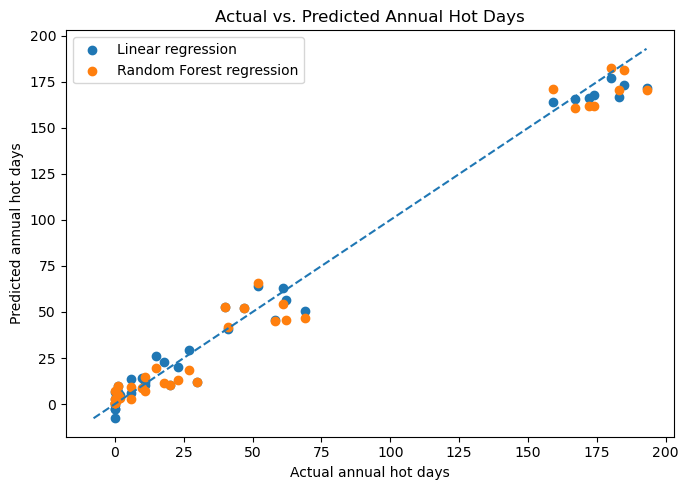

In [34]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, linear_pred, label='Linear regression')
plt.scatter(y_test, rf_pred, label='Random Forest regression')

min_val = min(y_test.min(), linear_pred.min(), rf_pred.min())
max_val = max(y_test.max(), linear_pred.max(), rf_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.title('Actual vs. Predicted Annual Hot Days')
plt.xlabel('Actual annual hot days')
plt.ylabel('Predicted annual hot days')
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
preprocessor = rf_model.named_steps['preprocess']
rf_estimator = rf_model.named_steps['model']

encoded_cat_features = (
    preprocessor
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)

all_feature_names = numeric_features + list(encoded_cat_features)

feature_importance = pd.DataFrame({
    'feature': all_feature_names,
    'importance': rf_estimator.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance

,feature,importance
4,prior_year_hot_days,0.538
11,climate_group_semi_arid,0.429
2,avg_temp_range_c,0.017
1,avg_precipitation,0.006
0,years_since_2000,0.004
3,rainy_days,0.002
7,region_Europe,0.001
5,coastal_city,0.001
10,climate_group_mediterranean,0.001
9,climate_group_humid_subtropical,0.000


The Random Forest relies most heavily on prior-year hot days and the semi-arid climate-group indicator. This is logical because annual heat exposure is persistent over time and because New Delhi, the only semi-arid city in this small sample, has much higher heat exposure than the other cities. The concentration of feature importance in a few variables also reinforces the main limitation of the project: the model is learning patterns within six selected cities, not a broad global forecasting rule.

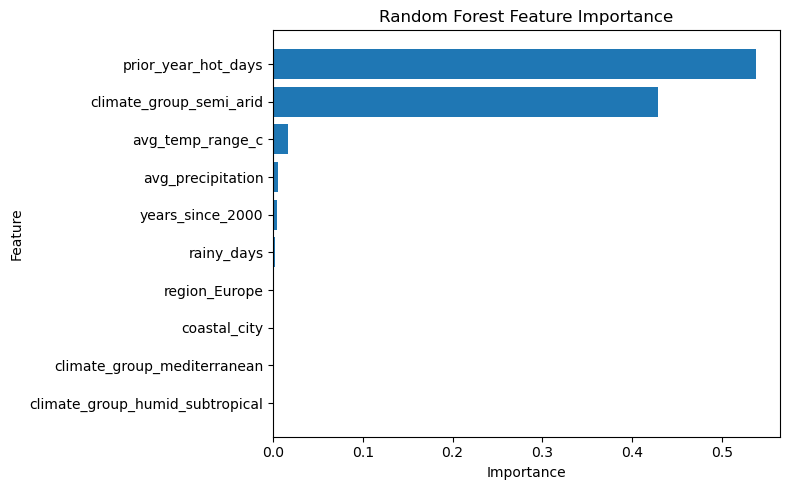

In [36]:
plot_df = feature_importance.head(10).sort_values('importance')

plt.figure(figsize=(8, 5))
plt.barh(plot_df['feature'], plot_df['importance'])
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [38]:
heldout_results = []

for heldout_city in model_df['city'].unique():
    train_df = model_df[model_df['city'] != heldout_city]
    test_df = model_df[model_df['city'] == heldout_city]

    X_train_city = train_df[feature_cols]
    y_train_city = train_df['hot_days']
    X_test_city = test_df[feature_cols]
    y_test_city = test_df['hot_days']

    city_model = Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', RandomForestRegressor(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=3,
            random_state=42
        )),
    ])

    city_model.fit(X_train_city, y_train_city)
    city_pred = city_model.predict(X_test_city)

    heldout_results.append({
        'held_out_city': heldout_city,
        'MAE': mean_absolute_error(y_test_city, city_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_city, city_pred)),
        'actual_avg_hot_days': y_test_city.mean(),
        'predicted_avg_hot_days': city_pred.mean(),
    })

heldout_city_results = pd.DataFrame(heldout_results).sort_values('MAE', ascending=False)
heldout_city_results

,held_out_city,MAE,RMSE,actual_avg_hot_days,predicted_avg_hot_days
2,New Delhi,125.238,126.279,171.360,46.122
1,Los Angeles,50.246,51.747,54.880,105.126
5,Tokyo,36.626,38.758,18.560,55.148
3,New York,8.447,11.911,13.200,14.402
0,London,3.224,3.293,0.680,3.723
4,Paris,2.291,2.679,4.200,4.278


The city-holdout validation shows that the model is much less reliable when predicting a city it did not see during training. This helps explain why the random train/test split produced very high R-squared values: the random split included years from the same six cities in both training and testing, so the model could learn persistent city-level climate patterns.

The model performs reasonably for cities with heat profiles similar to others in the sample, such as Paris, London, and New York. However, it performs poorly for more distinctive cities. New Delhi is severely underpredicted because no other city in the sample has a comparable level of heat exposure. Los Angeles and Tokyo are overpredicted, suggesting that the six-city sample is too small for the model to generalize confidently to unseen cities.

This does not invalidate the modeling section, but it changes the interpretation. The models should be viewed as structured checks that the engineered features explain heat exposure within the selected sample, not as production-ready models for predicting environmental risk in new global cities.

## 8. Interpretation and recommendations

The combined EDA and models point to several practical conclusions for a relocation-focused audience.

First, New Delhi is the highest-concern city in this sample. It combines the worst current AQI reading with the highest long-run share of hot days. This does not mean New Delhi is universally the least livable city, but it does mean that environmental health should be a major part of any relocation discussion.

Second, heat risk and air-quality risk should not be treated as the same issue. Los Angeles has relatively good current AQI in this snapshot but meaningful long-run heat exposure. London and Paris have moderate current AQI readings but much lower long-run heat exposure. This supports the value of looking at both current and historical environmental indicators.

Third, Tokyo and New York are important trend cases. They are not the hottest cities in the full historical sample, but their recent increase in hot days suggests that relocation teams should monitor whether heat exposure is worsening.

The modeling results support the EDA, but they should be interpreted cautiously. In the random train/test split, both the linear regression and Random Forest regression predict held-out city-years fairly well. The linear regression performs slightly better than the Random Forest in this version, which suggests that annual hot days are largely explained by stable climate and city-context features rather than by complex nonlinear interactions.

The most important modeling features are prior-year hot days and climate group. This is intuitive because heat exposure is persistent over time and strongly tied to local climate. Current AQI is not used as a heat-model predictor because it is a point-in-time air-quality snapshot, not a historical weather variable. Instead, current AQI is used as a separate current-risk dimension in the combined environmental risk score and AQI-versus-heat chart.

The city-holdout validation adds an important caution. When one entire city is held out of training, the model performs much worse for distinctive cities. New Delhi is severely underpredicted because no other city in the sample has a comparable level of heat exposure. Los Angeles and Tokyo are also misestimated, showing that the six-city sample is too small for the model to generalize confidently to unseen cities. The model performs better for Paris, London, and New York because their heat profiles are more similar to other cities in the sample.

Overall, the strongest practical recommendation is to evaluate relocation risk across more than one environmental dimension. New Delhi is the clearest high-concern case in this sample. Los Angeles is a heat concern even though its current AQI snapshot is relatively good. Tokyo and New York are trend-watch cases because their recent hot-day counts have increased. The models are useful as structured checks on the EDA, but they should not be treated as production-ready forecasting tools without a larger and more diverse city sample.

## Limitations

- Current AQI is a point-in-time snapshot, not a long-run air-quality average.
- The city sample is small and intentionally selected, so results should not be generalized to all global cities.
- The models are trained and tested on city-years from only six cities. The random train/test split predicts held-out years from known cities, not entirely new cities.
- The city-holdout validation shows that the model does not generalize well to distinctive unseen cities such as New Delhi, Los Angeles, and Tokyo.
- Weather and AQI do not directly measure health outcomes; they are environmental indicators.
- The city context table is simplified and should be expanded for a production-quality relocation analysis.

## Additional work with more time

With more time, we would add historical air-quality data, public-health outcomes, demographic vulnerability measures, and neighborhood-level data within each city. We would also expand the city sample and test model generalization by holding out entire cities or regions. This would make the environmental risk score more stable and more useful for real relocation decisions.